# Project 01: Exploratory Data Analysis 
- Jose Castillo-Flores

## Part 1
- Dataset: UCI Machine Learning Repository - Wine Quality
- URL: https://archive.ics.uci.edu/dataset/186/wine+quality


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")

# Load both CSVs
df_red = pd.read_csv("winequality-red.csv", sep=";")
df_white = pd.read_csv("winequality-white.csv", sep=";")

# Add color column
df_red["color"] = "red"
df_white["color"] = "white"

# Combine
df = pd.concat([df_red, df_white], ignore_index=True)

# Quick check
df.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [2]:
# Info and summary
df.info()
df.describe()

# Check missing values
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64

In [7]:

# Fill NaNs with forward fill, there is no NaN as previously showed, but just to show a process
df.fillna(method="ffill", inplace=True)

# Verify
df.isna().sum()


C:\Users\joser\AppData\Local\Temp\ipykernel_28252\1157760980.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64

In [22]:
# Filter wines with quality >= 8
df[df["quality"] >= 8].head(10)

# Sort by alcohol (descending)
df.sort_values(by="alcohol", ascending=False).head(10)

# Sort by multiple columns: alcohol then quality
df.sort_values(by=["alcohol", "quality"], ascending=[False, False]).head(10)




,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
652,15.9,0.360,0.65,7.5,0.096,22.0,71.0,0.99760,2.98,0.84,14.90,5,red
5517,6.4,0.350,0.28,1.6,0.037,31.0,113.0,0.98779,3.12,0.40,14.20,7,white
6102,5.8,0.610,0.01,8.4,0.041,31.0,104.0,0.99090,3.26,0.72,14.05,7,white
588,5.0,0.420,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.00,8,red
1269,5.5,0.490,0.03,1.8,0.044,28.0,87.0,0.99080,3.50,0.82,14.00,8,red
4544,4.9,0.330,0.31,1.2,0.016,39.0,150.0,0.98713,3.33,0.59,14.00,8,white
821,4.9,0.420,0.00,2.1,0.048,16.0,42.0,0.99154,3.71,0.74,14.00,7,red
2698,5.8,0.290,0.21,2.6,0.025,12.0,120.0,0.98940,3.39,0.79,14.00,7,white
5503,5.0,0.455,0.18,1.9,0.036,33.0,106.0,0.98746,3.21,0.83,14.00,7,white
5514,4.7,0.455,0.18,1.9,0.036,33.0,106.0,0.98746,3.21,0.83,14.00,7,white


In [24]:
# Average alcohol and quality by color
df.groupby("color")[["alcohol", "quality"]].mean().round(3)


,alcohol,quality
color,,
red,10.423,5.636
white,10.514,5.878


In [25]:
# Count wines by quality score
df["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

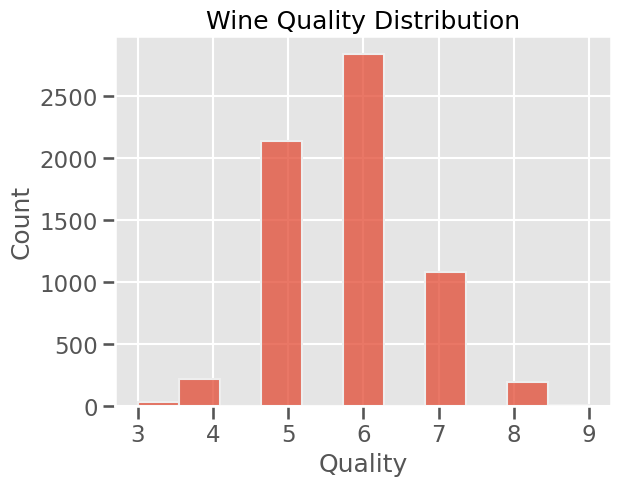

In [26]:
# Histogram of quality
sns.histplot(df["quality"], bins=11)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()


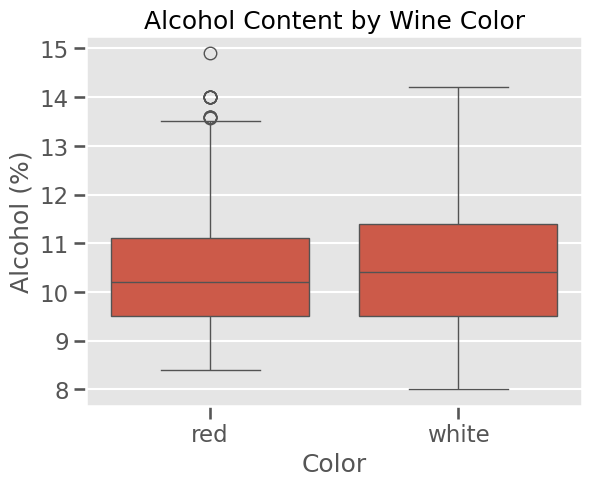

In [27]:

# Boxplot of alcohol by color
sns.boxplot(x="color", y="alcohol", data=df)
plt.title("Alcohol Content by Wine Color")
plt.xlabel("Color")
plt.ylabel("Alcohol (%)")
plt.show()


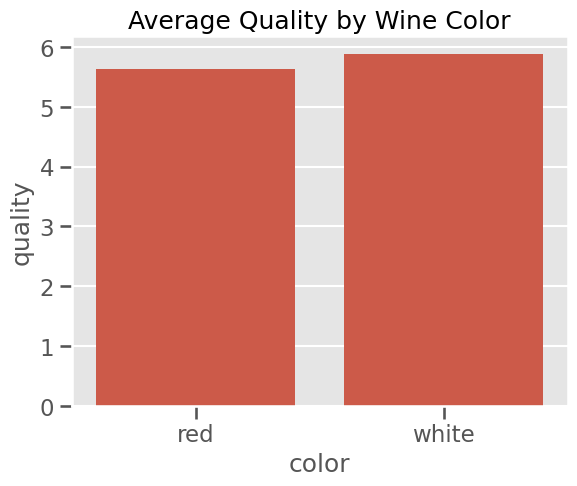

In [30]:

avg_quality = df.groupby("color")["quality"].mean().reset_index()
sns.barplot(x="color", y="quality", data=avg_quality)
plt.title("Average Quality by Wine Color")
plt.show()


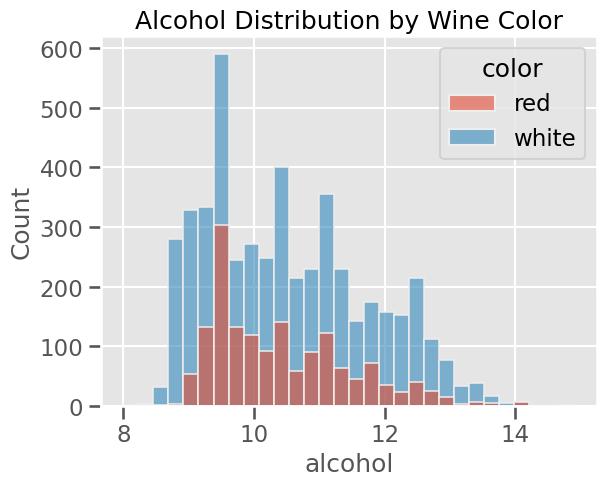

In [31]:

sns.histplot(data=df, x="alcohol", hue="color", bins=30, alpha=0.6)
plt.title("Alcohol Distribution by Wine Color")
plt.show()


### Summary
- Most wines have quality scores between 5 and 7.
- White wines tend to have slightly higher average alcohol content than red wines.


## Part 2 Kaggle
- Kaggle Titanic Dataset
- https://www.kaggle.com/competitions/titanic/overview

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")

# Load Kaggle Titanic train & test
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# combine both datasets
combined = pd.concat([
    train.assign(source="train"),
    test.assign(source="test").assign(Survived=np.nan)
], ignore_index=True)

print("Combined shape:", combined.shape)
combined.head()


Combined shape: (1309, 13)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,source
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


In [7]:
# Selecting the frame
df = combined

df.info()

# Summary of numeric columns
df.describe().T

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  source       1309 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 133.1+ KB


Cabin          1014
Survived        418
Age             263
Embarked          2
Fare              1
Sex               0
Name              0
Pclass            0
PassengerId       0
Ticket            0
Parch             0
SibSp             0
source            0
dtype: int64

In [8]:
# Make a clean copy
df_clean = df.copy()

# Fill 'Embarked' with mode (most frequent port), if missing
if "Embarked" in df_clean.columns:
    embarked_mode = df_clean["Embarked"].mode(dropna=True)
    if len(embarked_mode) > 0:
        df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode.iloc[0])

# Fill 'Age' with median by 'Sex' and 'Pclass' (basic, sensible imputation)
if {"Age", "Sex", "Pclass"}.issubset(df_clean.columns):
    df_clean["Age"] = df_clean.groupby(["Sex", "Pclass"])["Age"].transform(
        lambda s: s.fillna(s.median())
    )

# Cabin is highly missing; for simple EDA we can mark missing as 'Unknown'
if "Cabin" in df_clean.columns:
    df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

# Fare: fill any missing with median (rare in train; may occur in test)
if "Fare" in df_clean.columns:
    df_clean["Fare"] = df_clean["Fare"].fillna(df_clean["Fare"].median())

# Verify
df_clean.isna().sum().sort_values(ascending=False).head(10)


Survived       418
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [9]:

# Top 10 fares (descending)
df_clean.sort_values(by="Fare", ascending=False).head(10)

# Filter: Adults (Age >= 18) in 1st class
adults_first_class = df_clean[(df_clean["Age"] >= 18) & (df_clean["Pclass"] == 1)]
adults_first_class.head(10)

# Multi-key sort: by Pclass ascending, then Fare descending
df_clean.sort_values(by=["Pclass", "Fare"], ascending=[True, False]).head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,source
258,259,1.0,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,Unknown,C,train
679,680,1.0,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,train
737,738,1.0,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,train
1234,1235,NaN,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,test
27,28,0.0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,train
88,89,1.0,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,train
341,342,1.0,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S,train
438,439,0.0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,train
944,945,NaN,1,"Fortune, Miss. Ethel Flora",female,28.0,3,2,19950,263.0000,C23 C25 C27,S,test
960,961,NaN,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S,test


In [16]:
# Use only train rows for survival analysis
df_train_clean = df_clean[df_clean["source"].eq("train")] if "source" in df_clean.columns else df_clean

In [17]:
# Survival rate by Sex
survival_by_sex = df_train_clean.groupby("Sex")["Survived"].mean().round(3)
survival_by_sex

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

In [18]:
# Survival rate by Pclass
survival_by_pclass = df_train_clean.groupby("Pclass")["Survived"].mean().round(3)
survival_by_pclass

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

In [19]:
# Combined: Survival rate by Sex & Pclass
survival_by_sex_pclass = df_train_clean.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().round(3)
survival_by_sex_pclass

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


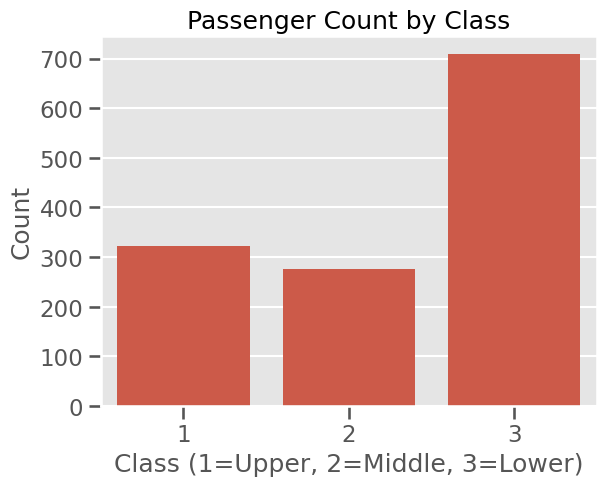

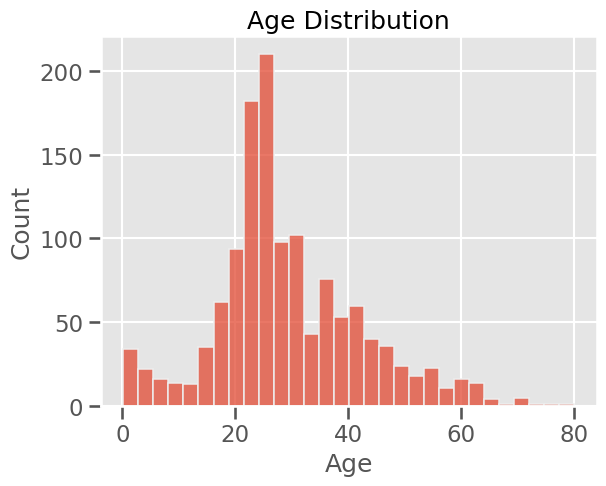

C:\Users\joser\AppData\Local\Temp\ipykernel_21868\163646955.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df_train_clean, estimator=np.mean, ci=None)


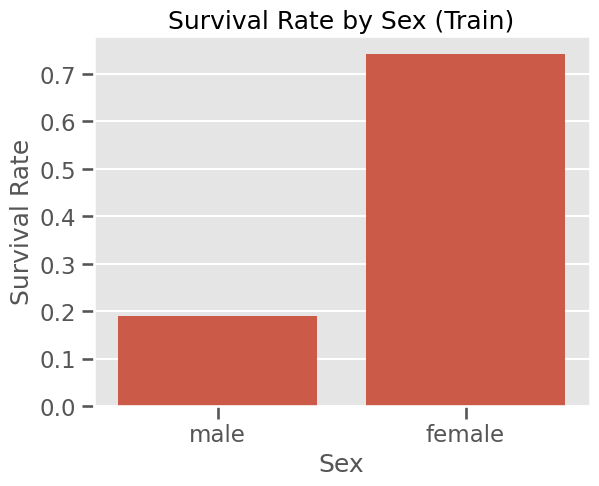

C:\Users\joser\AppData\Local\Temp\ipykernel_21868\163646955.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df_train_clean, estimator=np.mean, ci=None)


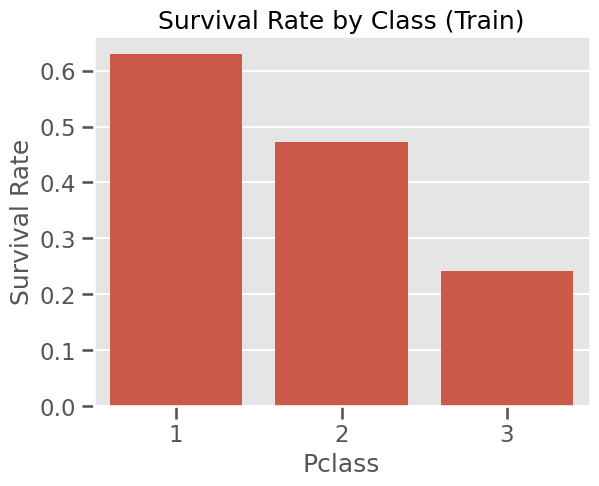

In [20]:

# Count of passengers by Pclass
sns.countplot(x="Pclass", data=df_clean)
plt.title("Passenger Count by Class")
plt.xlabel("Class (1=Upper, 2=Middle, 3=Lower)")
plt.ylabel("Count")
plt.show()

# Age distribution
sns.histplot(df_clean["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Survival rate by Sex
if "Survived" in df_train_clean.columns:
    sns.barplot(x="Sex", y="Survived", data=df_train_clean, estimator=np.mean, ci=None)
    plt.title("Survival Rate by Sex (Train)")
    plt.ylabel("Survival Rate")
    plt.show()

# Survival rate by Pclass
if "Survived" in df_train_clean.columns:
    sns.barplot(x="Pclass", y="Survived", data=df_train_clean, estimator=np.mean, ci=None)
    plt.title("Survival Rate by Class (Train)")
    plt.ylabel("Survival Rate")
    plt.show()


Passenger Count by Class: Most passengers were in 3rd class.
Age Distribution: Shows the age spread across all passengers; imputation ensures a continuous distribution without gaps.
Survival by Sex: Females had significantly higher survival rates than males (historically consistent with evacuation protocols).
Survival by Class: Higher class (1st) passengers had higher survival rates than lower classes.